In [1]:
pip install pyspark numpy jupyter matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================
# SE446 - Milestone 2: Spark Analytics (Phase A)
# Group: Altamimi-AlDeri
#
# Tasks 1, 2, 3, 4: Abdulaziz Altamimi (ID: 230714)
# ============================================
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Must be set before the JVM starts — fixes Windows "Python worker timeout" error
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
os.environ["_JAVA_OPTIONS"] = "-Djava.net.preferIPv4Stack=true"

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, when,
    round as spark_round
)

# Auto-detect environment: cluster vs local
ON_CLUSTER = (
    os.environ.get('YARN_CONF_DIR') is not None or
    os.environ.get('HADOOP_CONF_DIR') is not None or
    os.path.exists('/data/chicago_crimes.csv')
)

mode = 'CLUSTER' if ON_CLUSTER else 'LOCAL'
print(f'Running in {mode} mode')
print(f'Python executable: {sys.executable}')

if ON_CLUSTER:
    spark = (
        SparkSession.builder
        .appName('SE446-M2-PhaseA-Altamimi-AlDeri')
        .getOrCreate()
    )
else:
    spark = (
        SparkSession.builder
        .appName('SE446-M2-PhaseA-Altamimi-AlDeri')
        .master('local[*]')
        .config('spark.driver.memory', '2g')
        .config('spark.sql.shuffle.partitions', '4')
        .config('spark.pyspark.python', sys.executable)
        .config('spark.pyspark.driver.python', sys.executable)
        .getOrCreate()
    )

spark.sparkContext.setLogLevel('WARN')
os.makedirs('output', exist_ok=True)
print(f'Spark version: {spark.version}')
print(f'Web UI: {spark.sparkContext.uiWebUrl}')

Running in LOCAL mode
Python executable: c:\Users\Admin\python\python.exe
Spark version: 4.1.2
Web UI: http://WINDOWS-ISFVGL7.mshome.net:4040


In [3]:
# ============================================
# Data Loading / Generation
# Author: Abdulaziz Altamimi (ID: 230714)
# ============================================

import random
import pandas as pd

if ON_CLUSTER:
    DATA_PATH = 'hdfs:///data/chicago_crimes.csv'
    print(f'Loading data from HDFS: {DATA_PATH}')
    df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)
else:
    # ---- LOCAL MODE: Generate realistic sample data ----
    from pyspark.sql import Row
    import random
    random.seed(42)

    crime_profiles = {
        "NARCOTICS":         0.85,
        "PROSTITUTION":      0.80,
        "WEAPONS VIOLATION": 0.60,
        "BATTERY":           0.30,
        "ASSAULT":           0.25,
        "ROBBERY":           0.15,
        "THEFT":             0.10,
        "BURGLARY":          0.08,
        "MOTOR VEHICLE THEFT": 0.06,
        "CRIMINAL DAMAGE":   0.05,
    }
    districts = list(range(1, 26))

    LOCATIONS = [
        "STREET", "RESIDENCE", "APARTMENT", "SIDEWALK", "OTHER",
        "PARKING LOT / GARAGE(NON.RESID.)", "ALLEY",
        "SCHOOL, PUBLIC, BUILDING", "SMALL RETAIL STORE", "RESTAURANT"
    ]
    def generate_row():
        crime_type = random.choice(list(crime_profiles.keys()))
        base_rate = crime_profiles[crime_type]
        district = random.choice(districts)
        hour_val = random.randint(0, 23)
        domestic = random.random() < 0.15
        year = random.randint(2001, 2023)
        location=random.choice(LOCATIONS)
        arrest_prob = base_rate + (0.20 if domestic else 0)
        if 2 <= hour_val <= 5:
            arrest_prob -= 0.10
        arrest_prob = max(0.01, min(0.99, arrest_prob))
        arrest = random.random() < arrest_prob
        return Row(
            District=district, PrimaryType=crime_type,
            Hour=hour_val, Domestic_str=str(domestic).lower(),
            Arrest=arrest, label=int(arrest), Year=year, 
            LocationDescription=location
        )

    rows = [generate_row() for _ in range(10000)]
    df = spark.createDataFrame(rows)

    df = (df.withColumnRenamed('PrimaryType', 'Primary Type').withColumnRenamed('LocationDescription', 'Location Description'))

if ON_CLUSTER:
    total = df.count()
else:
    try:
        total = len(rows)
    except NameError:
        total = df.count()
print(f'Total records: {total:,}')
print('Schema:')
df.printSchema()
df.show(5, truncate=False)


Total records: 10,000
Schema:
root
 |-- District: long (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)
 |-- Year: long (nullable = true)
 |-- Location Description: string (nullable = true)

+--------+-------------------+----+------------+------+-----+----+--------------------+
|District|Primary Type       |Hour|Domestic_str|Arrest|label|Year|Location Description|
+--------+-------------------+----+------------+------+-----+----+--------------------+
|1       |PROSTITUTION       |23  |false       |true  |1    |2008|APARTMENT           |
|3       |MOTOR VEHICLE THEFT|18  |false       |false |0    |2001|RESIDENCE           |
|20      |MOTOR VEHICLE THEFT|0   |false       |false |0    |2023|SMALL RETAIL STORE  |
|19      |BURGLARY           |8   |false       |false |0    |2001|APARTMENT           |
|9       |ROBBERY           

---
## Phase A: Spark DataFrame Analytics


---
### Task 1: Crime Type Distribution (Spark DataFrame)

**Goal**: Count crimes by `Primary Type`, show top 10 ordered by count descending.  
**Author**: Abdulaziz Altamimi (ID: 230714)


In [4]:
# ============================================
# Task 1: Crime Type Distribution
# Author: Abdulaziz Altamimi (ID: 230714)
# ============================================
print('TASK 1: Crime Type Distribution (Spark DataFrame)')
print()
print('Top 10 Crime Types by Count:')

crime_dist = (
    df.groupBy("Primary Type")
      .count()
      .orderBy(col('count').desc())
).show(10, truncate=False)


TASK 1: Crime Type Distribution (Spark DataFrame)

Top 10 Crime Types by Count:
+-------------------+-----+
|Primary Type       |count|
+-------------------+-----+
|WEAPONS VIOLATION  |1065 |
|THEFT              |1054 |
|MOTOR VEHICLE THEFT|1005 |
|PROSTITUTION       |1005 |
|ASSAULT            |998  |
|NARCOTICS          |991  |
|BATTERY            |987  |
|BURGLARY           |976  |
|ROBBERY            |973  |
|CRIMINAL DAMAGE    |946  |
+-------------------+-----+



---
### Task 2: Location Hotspots (Spark SQL)

**Goal**: Find the top 10 crime location descriptions using `spark.sql()` — not the DataFrame API.  
**Author**: Abdulaziz Altamimi (ID: 230714)

In [5]:
# ============================================
# Task 2: Location Hotspots (Spark SQL)
# Author: Abdulaziz Altamimi (ID: 230714)
# ============================================
print('TASK 2: Location Hotspots (Spark SQL)')
print()
print('Top 10 Crime Location Hotspots:')

# Register DataFrame as a SQL temp view
df.createOrReplaceTempView("crimes")
hotspots = spark.sql("""
    SELECT `Location Description`, COUNT(*) as total
    FROM crimes
    GROUP BY `Location Description`
    ORDER BY total DESC
    LIMIT 10
""").show()


TASK 2: Location Hotspots (Spark SQL)

Top 10 Crime Location Hotspots:
+--------------------+-----+
|Location Description|total|
+--------------------+-----+
|               ALLEY| 1042|
|SCHOOL, PUBLIC, B...| 1029|
|               OTHER| 1027|
|          RESTAURANT| 1022|
|           APARTMENT|  998|
|           RESIDENCE|  993|
|              STREET|  992|
|  SMALL RETAIL STORE|  973|
|PARKING LOT / GAR...|  964|
|            SIDEWALK|  960|
+--------------------+-----+



---
### Task 3: Crime Trend Over Years (DataFrame + Visualization)

**Goal**: Show crime count per year; include a matplotlib line chart in local mode.  
**Author**: Abdulaziz Altamimi (ID: 230714)


TASK 3: Crime Trend Over Years

Crime Count Per Year:
 Year  count
 2001    425
 2002    411
 2003    441
 2004    428
 2005    447
 2006    420
 2007    442
 2008    459
 2009    444
 2010    426
 2011    434
 2012    428
 2013    464
 2014    430
 2015    406
 2016    386
 2017    462
 2018    413
 2019    444
 2020    420
 2021    421
 2022    479
 2023    470


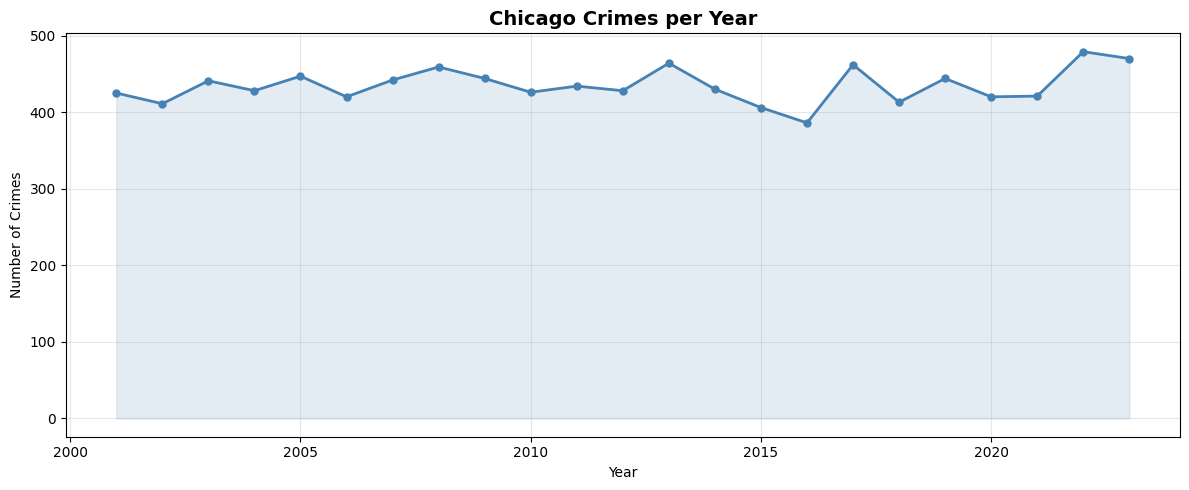

Chart saved to: output/task3_crime_trend.png


In [6]:
# ============================================
# Task 3: Crime Trend Over Years
# Author: Abdulaziz Altamimi (ID: 230714)
# ============================================

import matplotlib
import matplotlib.pyplot as plt

print('TASK 3: Crime Trend Over Years')

yearly = df.groupBy('Year').count().orderBy('Year').toPandas()
if ON_CLUSTER:
    matplotlib.use('Agg')
print()
print('Crime Count Per Year:')
print(yearly.to_string(index=False))

try:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yearly['Year'], yearly['count'],
            marker='o', color='steelblue', linewidth=2, markersize=5)
    ax.fill_between(yearly['Year'], yearly['count'], alpha=0.15, color='steelblue')
    ax.set_title('Chicago Crimes per Year', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Crimes')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = '/tmp/task3_crime_trend.png' if ON_CLUSTER else 'output/task3_crime_trend.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Chart saved to: {out_path}')
except Exception as e:
    print(f'Visualization skipped: {e}')


---
### Task 4: Arrest Rate Analysis (DataFrame)

**Goal**: Compute (a) overall arrest rate and (b) arrest rate broken down by crime type.  
**Author**: Abdulaziz Altamimi (ID: 230714)


In [ ]:
# ============================================
# Task 4: Arrest Rate Analysis
# Author: Abdulaziz Altamimi (ID: 230714)
# ============================================
print('TASK 4: Arrest Rate Analysis')

# Cast Arrest boolean to integer (0/1)
df = df.withColumn('label', col('Arrest').cast('integer'))

# Overall arrest rate
overall = df.agg(
    count('*').alias('total_crimes'),
    count(when(col('label') == 1, True)).alias('total_arrests'),
    (avg('label') * 100).alias('arrest_rate_pct')
).toPandas()

total_crimes = int(overall['total_crimes'][0])
total_arrests = int(overall['total_arrests'][0])
arrest_rate_pct = float(overall['arrest_rate_pct'][0])

print()
print('Overall Statistics:')
print(f'Total Crimes: {total_crimes:,}')
print(f'Total Arrests: {total_arrests:,}')
print(f'Arrest Rate: {arrest_rate_pct:.2f}%')

print()
print('Crime Types with Highest Arrest Rates:')

# Arrest rate per crime type
per_type = (
    df.groupBy("Primary Type")
      .agg(
          count('*').alias('total'),
          count(when(col('label') == 1, True)).alias('arrests')
      )
      .withColumn(
          'arrest_rate_pct',
          spark_round((col('arrests') / col('total')) * 100, 2)
      )
      .orderBy(col('arrest_rate_pct').desc())
).show()


TASK 4: Arrest Rate Analysis

Overall Statistics:
Total Crimes: 10,000
Total Arrests: 3,426
Arrest Rate: 34.26%

Crime Types with HIGHEST Arrest Rates (Top 10):
+-------------------+-----+-------+---------------+
|       Primary Type|total|arrests|arrest_rate_pct|
+-------------------+-----+-------+---------------+
|          NARCOTICS|  991|    849|          85.67|
|       PROSTITUTION| 1005|    821|          81.69|
|  WEAPONS VIOLATION| 1065|    663|          62.25|
|            BATTERY|  987|    307|           31.1|
|            ASSAULT|  998|    247|          24.75|
|            ROBBERY|  973|    170|          17.47|
|              THEFT| 1054|    116|          11.01|
|           BURGLARY|  976|    103|          10.55|
|MOTOR VEHICLE THEFT| 1005|     87|           8.66|
|    CRIMINAL DAMAGE|  946|     63|           6.66|
+-------------------+-----+-------+---------------+



In [ ]:
# Stop Spark session when done
spark.stop()
print('SparkSession stopped.')
